In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)

In [11]:
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = datasets.FashionMNIST(root="./data", train=True,  download=True, transform=tf)
val_set   = datasets.FashionMNIST(root="./data", train=False, download=True, transform=tf)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False)

# Task 1 — Train the Network

In [12]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),

    nn.Linear(64, 10)
).to(device)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): ReLU()
  (4): Dropout(p=0.3, inplace=False)
  (5): Linear(in_features=256, out_features=128, bias=True)
  (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): ReLU()
  (8): Dropout(p=0.3, inplace=False)
  (9): Linear(in_features=128, out_features=64, bias=True)
  (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (11): ReLU()
  (12): Linear(in_features=64, out_features=10, bias=True)
)


In [13]:
epochs = 15

loss_fn = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=epochs
)

In [14]:
def evaluate(model, data_loader, loss_fn, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)

            total_loss += loss.item() * X_batch.size(0)

            preds = torch.argmax(logits, dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

In [15]:
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):
    model.train()

    running_loss = 0
    correct = 0
    total = 0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
    scheduler.step()

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()

    val_running_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)
            val_running_loss += loss.item() * X_batch.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)
    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 01/15 | Train Loss: 0.5887 | Val Loss: 0.4095 | Train Acc: 0.8109 | Val Acc: 0.8507
Epoch 02/15 | Train Loss: 0.4034 | Val Loss: 0.3724 | Train Acc: 0.8540 | Val Acc: 0.8682
Epoch 03/15 | Train Loss: 0.3690 | Val Loss: 0.3663 | Train Acc: 0.8663 | Val Acc: 0.8667
Epoch 04/15 | Train Loss: 0.3452 | Val Loss: 0.3578 | Train Acc: 0.8744 | Val Acc: 0.8710
Epoch 05/15 | Train Loss: 0.3252 | Val Loss: 0.3295 | Train Acc: 0.8808 | Val Acc: 0.8829
Epoch 06/15 | Train Loss: 0.3085 | Val Loss: 0.3358 | Train Acc: 0.8869 | Val Acc: 0.8810
Epoch 07/15 | Train Loss: 0.2993 | Val Loss: 0.3141 | Train Acc: 0.8900 | Val Acc: 0.8849
Epoch 08/15 | Train Loss: 0.2846 | Val Loss: 0.3181 | Train Acc: 0.8950 | Val Acc: 0.8870
Epoch 09/15 | Train Loss: 0.2679 | Val Loss: 0.3000 | Train Acc: 0.9015 | Val Acc: 0.8917
Epoch 10/15 | Train Loss: 0.2562 | Val Loss: 0.2998 | Train Acc: 0.9055 | Val Acc: 0.8943
Epoch 11/15 | Train Loss: 0.2454 | Val Loss: 0.2952 | Train Acc: 0.9103 | Val Acc: 0.8945
Epoch 12/1

In [16]:
best_val_acc = max(val_accs)
best_epoch = val_accs.index(best_val_acc) + 1

print(f"Best validation accuracy: {best_val_acc:.4f}")
print(f"Best epoch: {best_epoch}")

Best validation accuracy: 0.8991
Best epoch: 15


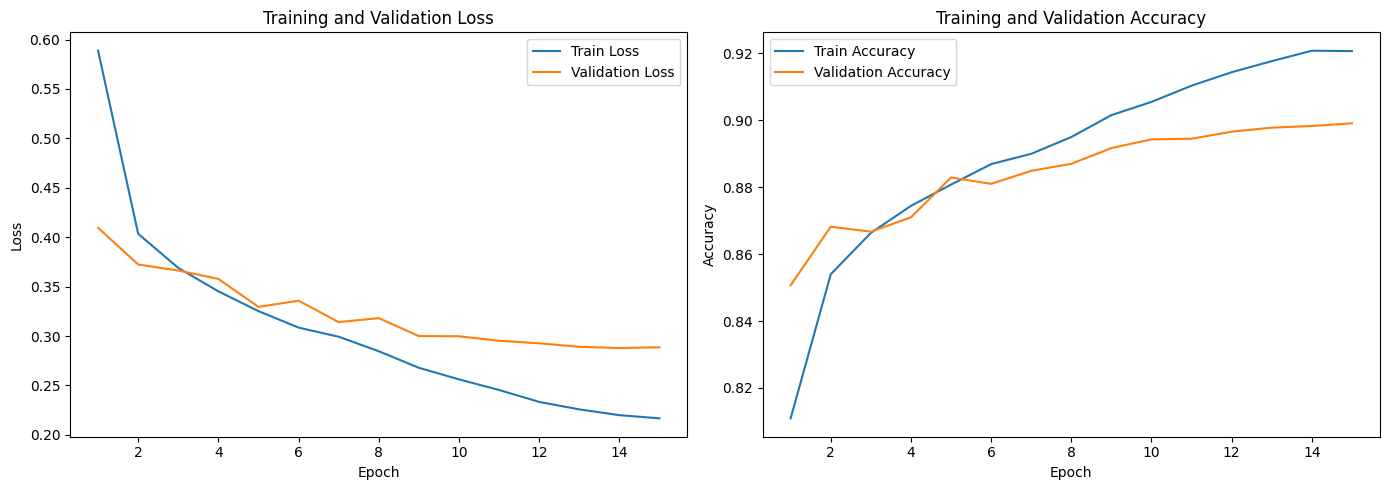

In [17]:
epochs_range = range(1, epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_range, train_losses, label="Train Loss")
axes[0].plot(epochs_range, val_losses, label="Validation Loss")
axes[0].set_title("Training and Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[1].plot(epochs_range, train_accs, label="Train Accuracy")
axes[1].plot(epochs_range, val_accs, label="Validation Accuracy")
axes[1].set_title("Training and Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

The training and validation loss both decrease across the 15 epochs, while the training and validation accuracy steadily improve. The curves stay reasonably close, so there is no strong sign of overfitting. The best validation accuracy was 89.91% at epoch 15, and the model was still slightly improving at the end.